# Spam Model Evaluation

Za danasnji task cu porediti vise modela za detekciju spam poruka.
Cilj mi je da vidim koji model najbolje prepoznaje spam,sto cu na kraju i obrazloziti.

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Ucitavanje i analiza podataka

Prvo cu cuitati podatke i pogledati osnovne informacije,koliko poruka imam,da li imam praznih vrijednosti i koje vrijednosti postoje u koloni category.



In [29]:
from google.colab import files
uploaded = files.upload()

Saving messages.csv to messages (2).csv


In [30]:
podaci = pd.read_csv('messages.csv')
print(podaci.head())
print("\nBroj poruka ukupno:",len(podaci))
print("\nBroj nedostajucih vrijednosti po koloni:")
print(podaci.isnull().sum())
print("\nSve raclicite vrijednosti u koloni category:")
print(podaci["category"].unique())


  category                                            message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Broj poruka ukupno: 5569

Broj nedostajucih vrijednosti po koloni:
category    111
message      55
dtype: int64

Sve raclicite vrijednosti u koloni category:
['ham' 'spam' 'not spam' nan]


## Ciscenje i priprema podataka

Kolona category sadrzi i prazne vrijednosti i vrijednosti not spam,zato cu ukloniti prazne redove i standardizovati sve vrijednosti tako da ostanu samo spam i ham.

In [31]:
podaci = podaci.dropna(subset=['message','category'])
podaci['category']=podaci['category'].str.lower()
podaci['category']=podaci['category'].str.strip()
podaci['category']=podaci['category'].replace('not spam','ham')
podaci=podaci[podaci['category'].isin(['spam','ham'])]
print("Vrijednosti u category nakon ciscenja:")
print(podaci['category'].unique())
print("\nBroj redova nakon ciscenja:",len(podaci))
print("\nOdnos spam/ham poruka:")
print(podaci['category'].value_counts())

Vrijednosti u category nakon ciscenja:
['ham' 'spam']

Broj redova nakon ciscenja: 5404

Odnos spam/ham poruka:
category
ham     4682
spam     722
Name: count, dtype: int64


# Podjela podataka na trening i test skup

Sada cu podijeliti podatke na trening i test skup.Koristit cu odnos 80/20.

In [32]:
x=podaci['message']
y=podaci['category']
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)
print("Broj poruka u trening skupu:",len(x_train))
print("Broj poruka u test skupu:",len(x_test))

Broj poruka u trening skupu: 4323
Broj poruka u test skupu: 1081


## Vektorizacija teksta

Sada cu pretvoriti poruke u brojeve,jer modeli ne razumiju tekst.

In [33]:
vektorizator=TfidfVectorizer()
x_train_vek=vektorizator.fit_transform(x_train)
x_test_vek=vektorizator.transform(x_test)

## Treniranje vise modela

Pravim rijecnik sa 4 razlicita modela i svaki od njih treniram na trening pdoacima i pravim predikcije na test podacima.

In [34]:
modeli={
    "Logistic Regression":LogisticRegression(),
    "Naive Bayes":MultinomialNB(),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "linear SVC":LinearSVC()
}

predikcije ={}

for ime_modela in modeli:
  model=modeli[ime_modela]
  model.fit(x_train_vek,y_train)
  predikcije[ime_modela]=model.predict(x_test_vek)
  print(ime_modela,'-treniran')

Logistic Regression -treniran
Naive Bayes -treniran
Decision Tree -treniran
linear SVC -treniran


## Evaluacija performansi

Za svaki model prikazat cu tacnost,klasifikacioni izvjestaj i matricu zabune.

----------------------------------------
Logistic Regression
----------------------------------------
Tacnost(accuracy): 0.9722

Klasifikacioni izvjestaj:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       937
        spam       0.98      0.81      0.89       144

    accuracy                           0.97      1081
   macro avg       0.98      0.90      0.93      1081
weighted avg       0.97      0.97      0.97      1081



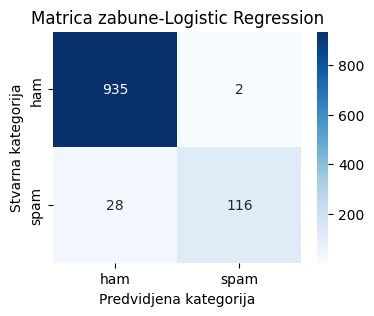

----------------------------------------
Naive Bayes
----------------------------------------
Tacnost(accuracy): 0.9602

Klasifikacioni izvjestaj:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       937
        spam       1.00      0.70      0.82       144

    accuracy                           0.96      1081
   macro avg       0.98      0.85      0.90      1081
weighted avg       0.96      0.96      0.96      1081



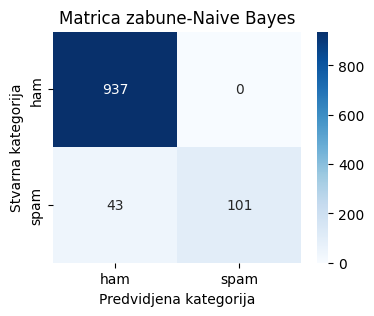

----------------------------------------
Decision Tree
----------------------------------------
Tacnost(accuracy): 0.9667

Klasifikacioni izvjestaj:
              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       937
        spam       0.89      0.85      0.87       144

    accuracy                           0.97      1081
   macro avg       0.93      0.92      0.93      1081
weighted avg       0.97      0.97      0.97      1081



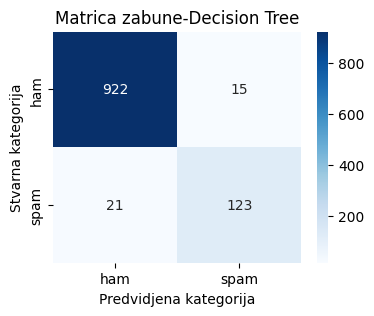

----------------------------------------
linear SVC
----------------------------------------
Tacnost(accuracy): 0.9889

Klasifikacioni izvjestaj:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       937
        spam       0.99      0.93      0.96       144

    accuracy                           0.99      1081
   macro avg       0.99      0.96      0.98      1081
weighted avg       0.99      0.99      0.99      1081



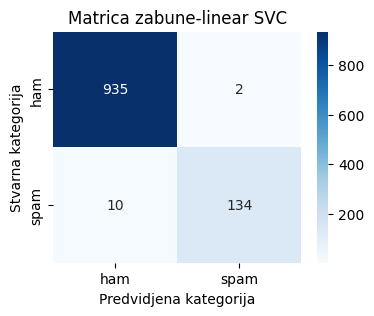

In [35]:
for ime_modela in modeli:
  pred=predikcije[ime_modela]
  print('-'*40)
  print(ime_modela)
  print('-'*40)
  acc=accuracy_score(y_test,pred)
  print("Tacnost(accuracy):",round(acc,4))
  print("\nKlasifikacioni izvjestaj:")
  print(classification_report(y_test,pred))
  matrica=confusion_matrix(y_test,pred,labels=['ham','spam'])
  plt.figure(figsize=(4,3))
  sns.heatmap(matrica,annot=True,fmt='d',cmap="Blues",
              xticklabels=['ham','spam'],yticklabels=['ham','spam'])
  plt.xlabel('Predvidjena kategorija')
  plt.ylabel("Stvarna kategorija")
  plt.title(f'Matrica zabune-{ime_modela}')
  plt.show()

## Zakljucak

Sva cetiri modela psotizu visoku tacnosti preko 96%,ali kada pogledam detaljnije preciznost,odziv i F1 skor za spam kategoriju,razlike postaju vidljivije.
Najbolje rezultate postize Linear SVC sa tacnoscu od skoro 99% i F! skorom od 0.96 za spam kategoriju.Logistic Regression je takodjer dala solidne rezultate,ali sa nizim odzivom za spam oko 0.81.NAive Bayes ima najvisu preciznost za spam skoro 100%,ali je odziv najnizi 0.70.Decision Tree je najslabiji od sva cetiri modela.
Za izbor modela izabrao bih uvijek onaj koji daje najbolji F1 skor za spam kategoriju,jer on pokazuje najbolji balans preciznosti i odziva.Preporucio bih timu da koristi Linear SVC model,jer nudi najbolji balans izmedju svih metrika i najbolje prepoznaje prave spam poruke
